In [22]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load data
train_data = pd.read_csv('Datasets/DailyDelhiClimateTrain.csv', index_col='date', parse_dates=True)
test_data = pd.read_csv('Datasets/DailyDelhiClimateTest.csv', index_col='date', parse_dates=True)

train_values = train_data.values
test_values = test_data.values

T = 7   # Number of time steps to look back
humidity_idx = train_data.columns.get_loc('humidity')

# Prepare datasets
def make_dataset(values, T, humidity_idx):
    X = []
    Y = []
    for t in range(len(values) - T):
        X.append(values[t:t+T])
        Y.append(values[t+T][humidity_idx])
    return np.array(X), np.array(Y)

# Normalize data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_values)
X_train, Y_train = make_dataset(train_scaled, T, humidity_idx)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (1455, 7, 4)
Y_train shape: (1455,)


In [23]:
# Build the LSTM model
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features]
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(units=1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, Y_train, epochs=100, batch_size=64)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6548
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3949
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3330
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3148
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3039
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2945
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2858
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2783
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2713
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2644
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2575
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2512
Epoch 13/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2452
Epoch 14/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2418
Epoch 15/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2329
Epoc

In [24]:
# Test evaluation
test_scaled = scaler.transform(test_values)
X_test, Y_test = make_dataset(test_scaled, T, humidity_idx)

test_loss = lstm_model.evaluate(X_test, Y_test, batch_size=64)
print("Test Loss:", test_loss)

Y_pred_scaled = lstm_model.predict(X_test).reshape(-1, 1)
Y_test_scaled = Y_test.reshape(-1, 1)

# Inverse scaling function
def inverse_humidity(scaled_col, scaler, humidity_idx, n_features):
    # scaled_col: shape (n_samples, 1)
    tmp = np.zeros((scaled_col.shape[0], n_features))
    tmp[:, humidity_idx] = scaled_col[:, 0]
    inv = scaler.inverse_transform(tmp)
    return inv[:, humidity_idx]

n_features = train_values.shape[1]

Y_pred_orig = inverse_humidity(Y_pred_scaled, scaler, humidity_idx, n_features)
Y_test_orig = inverse_humidity(Y_test_scaled, scaler, humidity_idx, n_features)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1778 
Test Loss: 0.1778128743171692
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


RMSE (humidity %): 7.069
MAE  (humidity %): 5.477


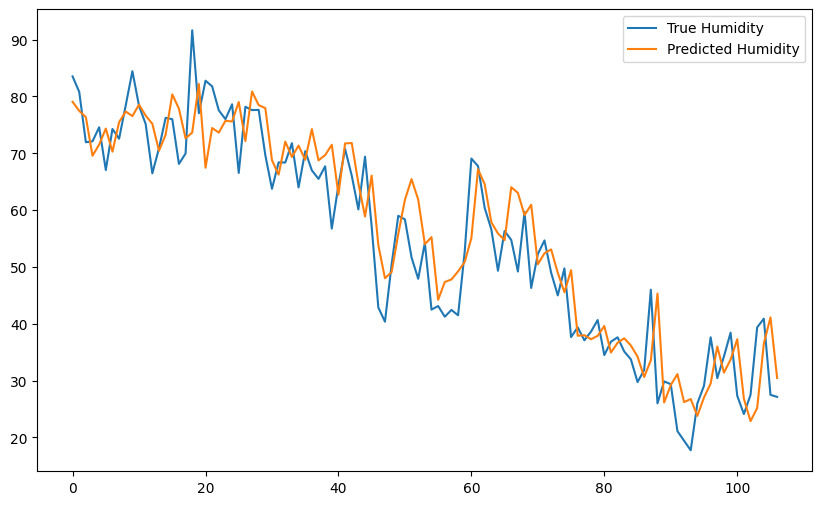

In [ ]:
# Performance metrics
rmse = np.sqrt(mean_squared_error(Y_test_orig, Y_pred_orig))
mae = mean_absolute_error(Y_test_orig, Y_pred_orig)

print(f"RMSE (humidity %): {rmse:.3f}")
print(f"MAE  (humidity %): {mae:.3f}")

plt.figure(figsize=(10,6))
plt.plot(Y_test_orig, label='True Humidity')
plt.plot(Y_pred_orig, label='Predicted Humidity')
plt.legend()
plt.show()